Extract OCR text per frame (or use transcript if available).

Embed text (e.g., BERT) and detect changes or train a classifier on text embeddings to mark important frames.

In [1]:
import os
import pandas as pd
import cv2
from PIL import Image
import pytesseract
from transformers import BertTokenizer, BertModel
import torch
import numpy as np


/Users/satyabratasatapathy/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/satyabratasatapathy/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Paths and setup
screenshot_dir = "./yt_screenshots"     # folder where frame images are stored
csv_path = "./yt_csv/screenshots.csv"   # your existing CSV with columns: filename, timestamp
output_csv = "./yt_csv/screenshots_with_ocr.csv"

# 2. Load CSV
df = pd.read_csv(csv_path)

In [3]:
 
print(df.columns)  # see which columns exist


Index(['filename', 'timestamp (seconds)'], dtype='object')


In [ ]:
import os
import pandas as pd
import easyocr

reader = easyocr.Reader(['en'])

# OCR function using EasyOCR
def ocr_text_for_image(image_path):
    try:
        result = reader.readtext(image_path, detail=0, paragraph=True)
        return " ".join(result).strip()
    except Exception as e:
        print(f"Error reading {image_path}: {e}")
        return ""

# Extract OCR text for each image
ocr_texts = []
for idx, row in df.iterrows():
    fname = row['filename']
    img_path = os.path.join(screenshot_dir, fname)
    text = ocr_text_for_image(img_path)
    ocr_texts.append(text)
    if idx % 50 == 0 and idx > 0:
        print(f"✅ OCR done for {idx}/{len(df)} frames")

# Add OCR result to DataFrame
df['ocr_text'] = ocr_texts

# Save updated DataFrame with OCR column
df.to_csv(output_csv, index=False)
print(f"✅ Saved augmented CSV with EasyOCR text to: {output_csv}")


/Users/satyabratasatapathy/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ OCR done for 50/418 frames
✅ OCR done for 100/418 frames
✅ OCR done for 150/418 frames
✅ OCR done for 200/418 frames
✅ OCR done for 250/418 frames
✅ OCR done for 300/418 frames
✅ OCR done for 350/418 frames
✅ OCR done for 400/418 frames
✅ Saved augmented CSV with EasyOCR text to: ./yt_csv/screenshots_with_ocr.csv


In [5]:

# 2. Load CSV
df = pd.read_csv(output_csv )

In [6]:
import pandas as pd
import nltk
from nltk.corpus import words
import re

# Download once if not already
nltk.download('words')

# Load valid English words
english_vocab = set(words.words())

# Define the cleaner, excluding single-letter tokens
def clean_text_keep_dict_words(text):
    text = str(text).lower()
    tokens = re.findall(r'\b[a-z]+\b', text)  # extract only alphabetic tokens
    # Keep only dictionary words of length > 1
    valid_words = [w for w in tokens if len(w) > 1 and w in english_vocab]
    return " ".join(valid_words)

# Load your original CSV with OCR
df = pd.read_csv("./yt_csv/screenshots_with_ocr.csv")

# Fill NaNs in 'ocr_text' and preprocess
df['ocr_text'] = df['ocr_text'].fillna("")
df['ocr_text_cleaned'] = df['ocr_text'].apply(clean_text_keep_dict_words)

# Save to new CSV
output_path = "./yt_csv/screenshots_with_cleaned_text.csv"
df.to_csv(output_path, index=False)

print(f"✅ Preprocessed OCR text saved to: {output_path}")
print(df[['filename', 'ocr_text', 'ocr_text_cleaned']].head())


✅ Preprocessed OCR text saved to: ./yt_csv/screenshots_with_cleaned_text.csv
          filename                                           ocr_text  \
0  frame_00000.jpg                                                      
1  frame_00001.jpg            BIOLO6Y SMALL INTESTINE Food AbsorptiOn   
2  frame_00002.jpg          BIOLOCY SMALL INTESTINE & FOOD ABSORPTION   
3  frame_00003.jpg  BIOLOCY SMALL INTESTINE & FOOD ABSORPTION fe s...   
4  frame_00004.jpg  BiOLOCY SMALL INTESTINE & FOOD ABSORPTION fure...   

                            ocr_text_cleaned  
0                                             
1            small intestine food absorption  
2            small intestine food absorption  
3  small intestine food absorption fe school  
4     small intestine food absorption school  


[nltk_data] Downloading package words to
[nltk_data]     /Users/satyabratasatapathy/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [7]:
# 6. Load BERT
import torch
from transformers import BertTokenizer, BertModel
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased').to(device)
bert.eval()

def embed_text(text, max_length=128):
    # clean or preprocess text if desired
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                       max_length=max_length, padding='max_length')
    inputs = {k: v.to(device) for k,v in inputs.items()}
    with torch.no_grad():
        out = bert(**inputs)
    cls_emb = out.last_hidden_state[:,0,:]  # (1,768)
    return cls_emb.squeeze(0).cpu().numpy()

# 7. Embed all OCR texts (cache to disk to avoid repeating)
embeddings = []
for idx, text in enumerate(df['ocr_text_cleaned'].astype(str)):
    emb = embed_text(text)
    embeddings.append(emb)
    if idx % 50 == 0 and idx > 0:
        print(f"Embedded {idx}/{len(df)} texts")
embeddings = np.stack(embeddings, axis=0)  # shape (num_frames, 768)
# Optionally save:
np.save("./yt_csv/ocr_text_embeddings.npy", embeddings)


Embedded 50/418 texts
Embedded 100/418 texts
Embedded 150/418 texts
Embedded 200/418 texts
Embedded 250/418 texts
Embedded 300/418 texts
Embedded 350/418 texts
Embedded 400/418 texts


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load DataFrame and text embeddings
df = pd.read_csv("./yt_csv/screenshots_with_cleaned_text.csv")
text_embeds = np.load("./yt_csv/ocr_text_embeddings.npy")
assert len(df) == len(text_embeds)

# 2. Normalize embeddings
te_norm = text_embeds / np.maximum(np.linalg.norm(text_embeds, axis=1, keepdims=True), 1e-8)

# 3. Compute sims between consecutive frames
N = len(df)
sims = np.ones(N)
for i in range(1, N):
    sims[i] = float(cosine_similarity(te_norm[[i]], te_norm[[i-1]])[0,0])

# 4. Detect change points
threshold = 0.8  # adjust if needed
change_pts = [0]
for i in range(1, N):
    if sims[i] < threshold:
        change_pts.append(i)
change_pts.append(N)

# 5. Compute text lengths
text_lengths = df['ocr_text_cleaned'].fillna("").apply(lambda x: len(x.split())).values

# 6. Pick one frame per segment, but skip segments with no text
selected = []
for k in range(len(change_pts)-1):
    start = change_pts[k]
    end = change_pts[k+1]
    if start >= end:
        continue
    seg_text_lengths = text_lengths[start:end]
    max_len = seg_text_lengths.max()
    if max_len == 0:
        # skip this segment entirely (no text in any frame)
        continue
    # pick index of max text length
    rel = int(np.argmax(seg_text_lengths))
    global_idx = start + rel
    selected.append(global_idx)

# 7. Remove duplicates and sort
selected = sorted(set(selected))

# 8. Export keyframes
key_df = df.iloc[selected][['filename', 'timestamp (seconds)', 'ocr_text_cleaned']]
key_df.to_csv("./yt_csv/keyframes_by_segment_nonempty.csv", index=False)
print(f"Selected {len(selected)} frames (skipping segments with no text).")
print(key_df.head())


Selected 30 frames (skipping segments with no text).
           filename  timestamp (seconds)  \
3   frame_00003.jpg                  1.5   
45  frame_00045.jpg                 22.5   
50  frame_00050.jpg                 25.0   
51  frame_00051.jpg                 25.5   
70  frame_00070.jpg                 35.0   

                                     ocr_text_cleaned  
3           small intestine food absorption fe school  
45    digestive system digestion absorption excretion  
50                                                 ex  
51                                    small intestine  
70  digestion breakdown of food from large insolub...  


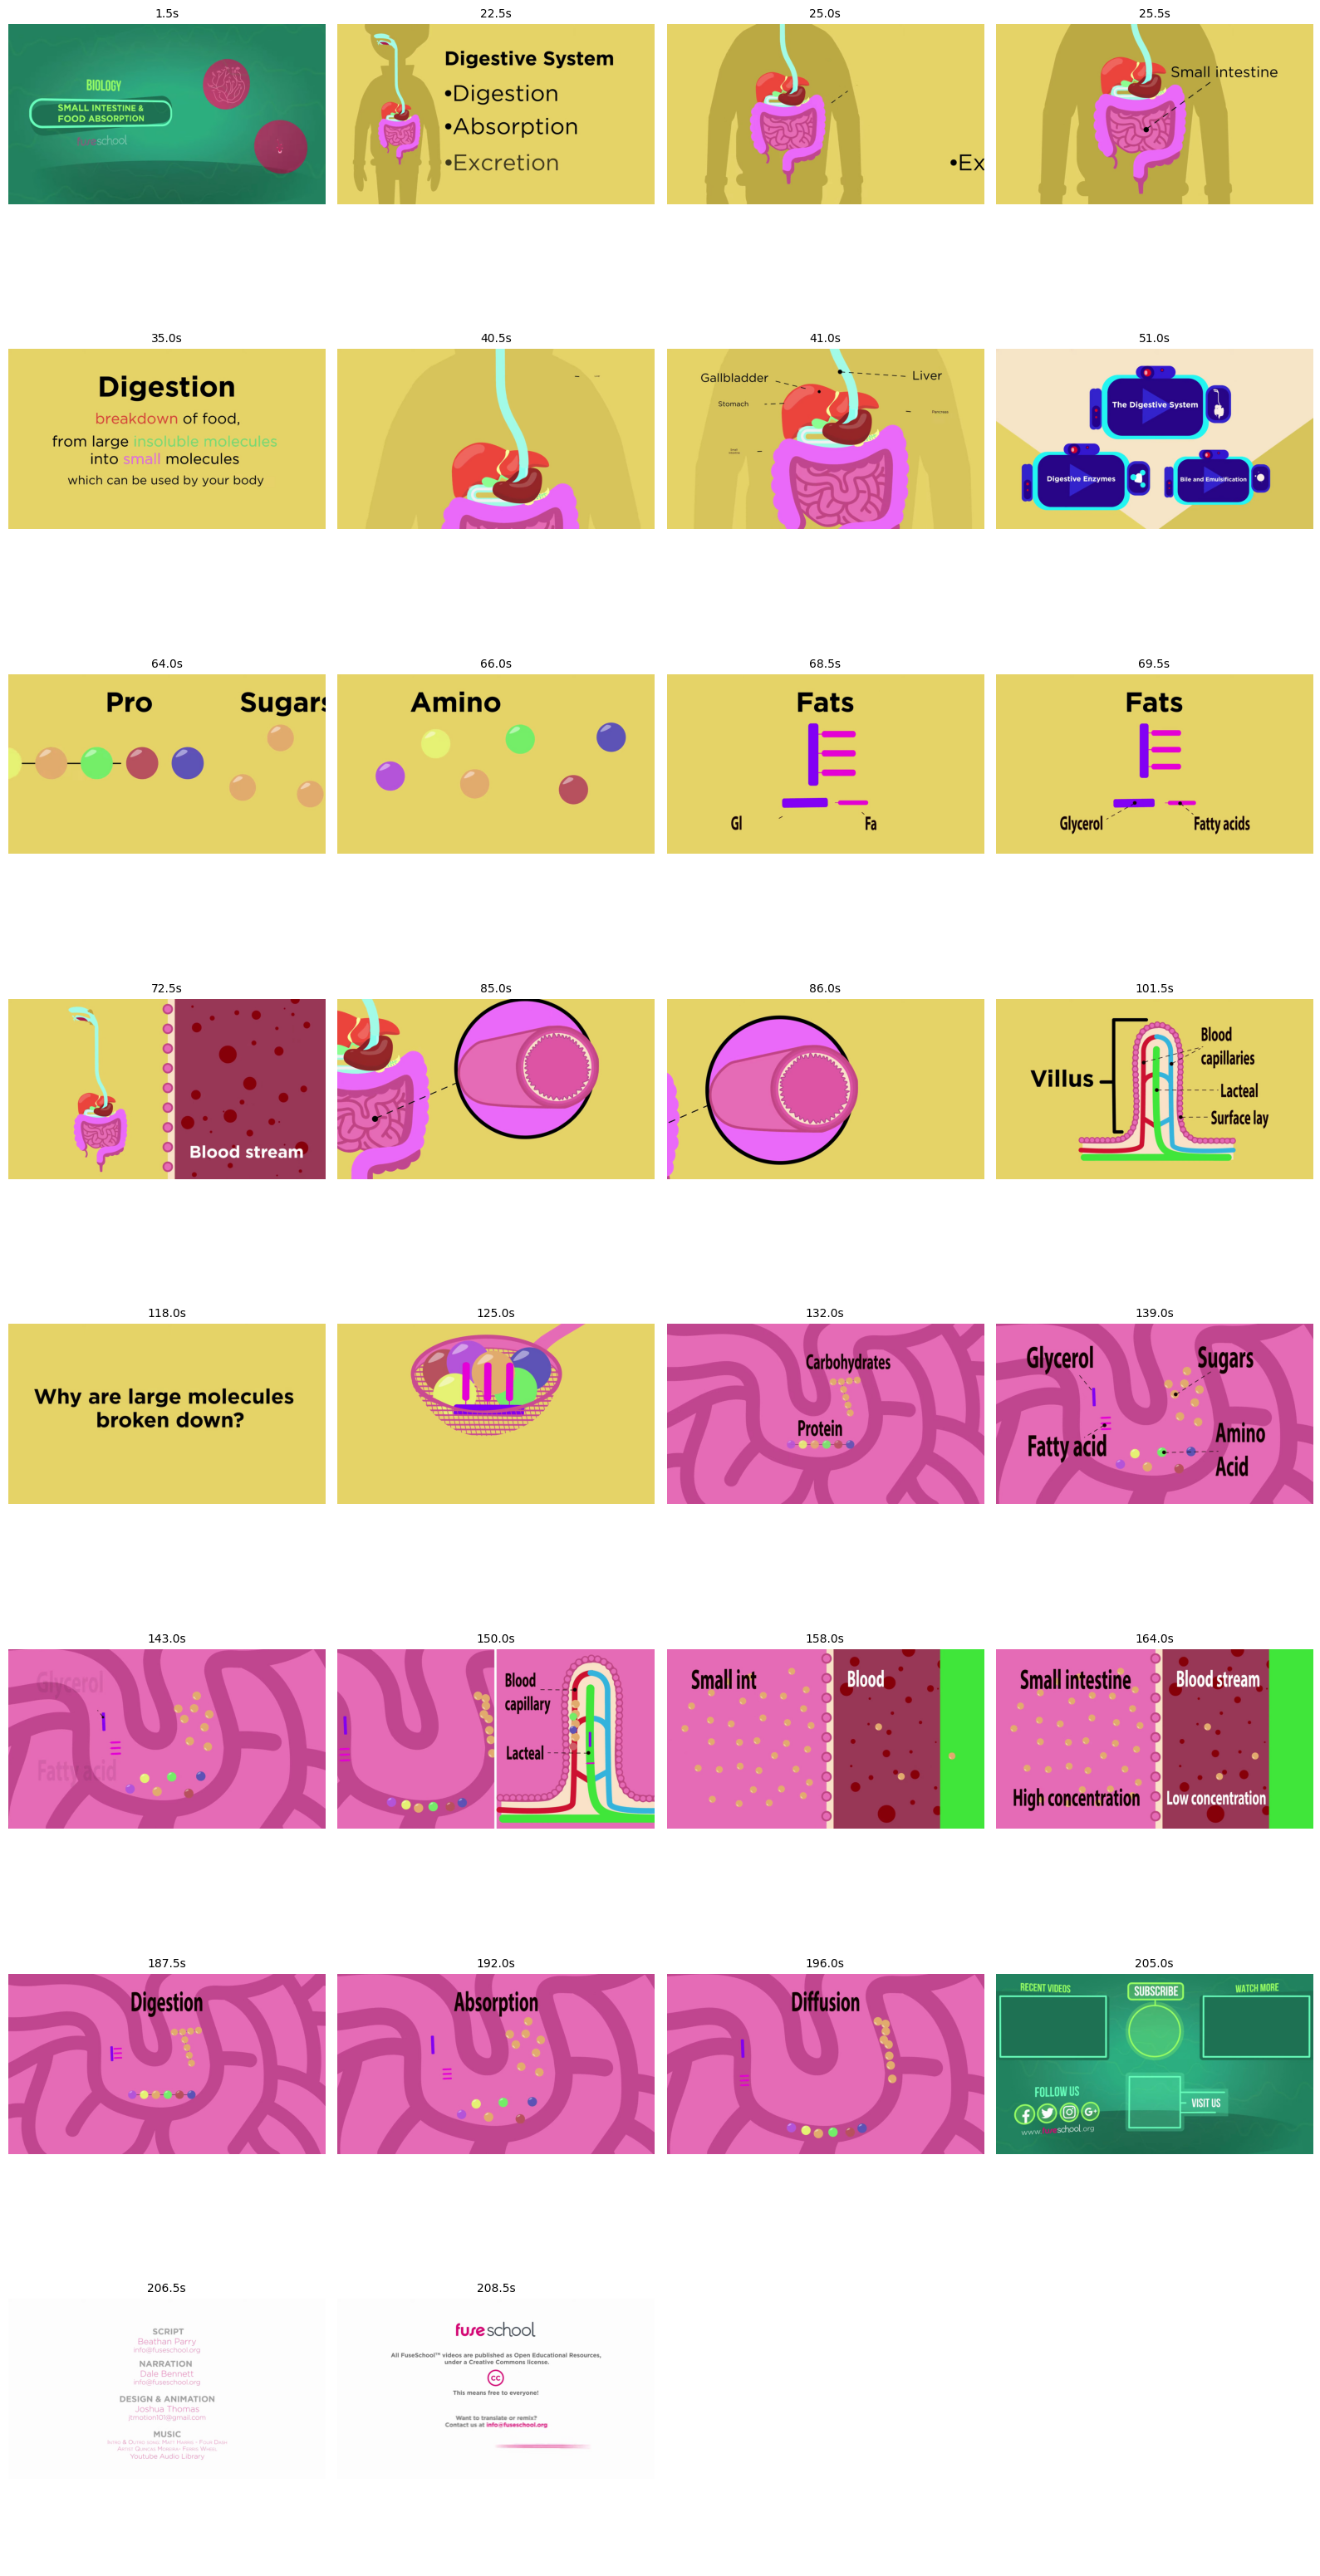

In [9]:
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt

# Load CSV
# df = pd.read_csv('./yt_csv/final_keyframes_time_aware.csv')
# df = pd.read_csv('./yt_csv/keyframes_sliding_window.csv')
df = pd.read_csv('./yt_csv/keyframes_by_segment_nonempty.csv')
# Define image folder
img_folder = './yt_screenshots'

# Set number of columns in the plot grid
n_cols = 4
n_images = len(df)
n_rows = (n_images + n_cols - 1) // n_cols

# Create plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, (i, row) in enumerate(df.iterrows()):
    img_path = os.path.join(img_folder, row['filename'])
    image = Image.open(img_path)

    axes[idx].imshow(image)
    axes[idx].set_title(f"{row['timestamp (seconds)']:.1f}s", fontsize=10)
    axes[idx].axis('off')

# Hide empty subplots
for ax in axes[n_images:]:
    ax.axis('off')

plt.tight_layout()
plt.show()
